# Exploratory Data Analysis (EDA)

Shared notebook for initial dataset exploration.

**Contributors**: All team members can add cells here.

In [11]:
# ----------------------------------------------------------------------------
# Importaciones
# ----------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Agrega el directorio raíz del proyecto al path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_loader import load_dataset, clean_data_id_gender, get_train_test_split , impute_bmi_knn, TARGET_COL
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Librerías importadas correctamente")

Librerías importadas correctamente


## Carga del DataSet

In [12]:
df_original = load_dataset()
df = df_original.copy()

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()

Loaded dataset: 5110 rows, 12 columns.
Dataset cargado: 5,110 filas x 12 columnas


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## BLOQUE 1 — Análisis Exploratorio de Datos (EDA)

### 1.1 Inspección inicial
Revisamos dimensiones, tipos de datos y estadísticos generales del dataset.

In [13]:
print("=" * 60)
print("INFORMACIÓN GENERAL")
print("=" * 60)
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas\n")
print("Tipos de variables:")
print(df.dtypes)
print("\nResumen estadístico:")
df.describe()

INFORMACIÓN GENERAL
Dimensiones: 5,110 filas x 12 columnas

Tipos de variables:
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

Resumen estadístico:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [14]:
vars_numericas   = ['age', 'avg_glucose_level', 'bmi']
vars_binarias    = ['hypertension', 'heart_disease', 'stroke']
vars_categoricas = ['gender', 'ever_married', 'work_type',
                    'Residence_type', 'smoking_status']

print("Variables numéricas:  ", vars_numericas)
print("Variables binarias:   ", vars_binarias)
print("Variables categóricas:", vars_categoricas)
print("Identificador:         ['id'] -> se eliminará")

Variables numéricas:   ['age', 'avg_glucose_level', 'bmi']
Variables binarias:    ['hypertension', 'heart_disease', 'stroke']
Variables categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
Identificador:         ['id'] -> se eliminará


### 1.2 Análisis del Target — Desbalance de Clases

El target `stroke` indica si el paciente sufrió un ACV (1) o no (0).
Es crítico analizar el desbalance antes de elegir métricas y estrategias.

Distribución del target 'stroke':
  Clase 0 (Sin ACV):  4,861 (95.1%)
  Clase 1 (Con ACV):  249 (4.9%)

  Ratio desbalance: 20:1


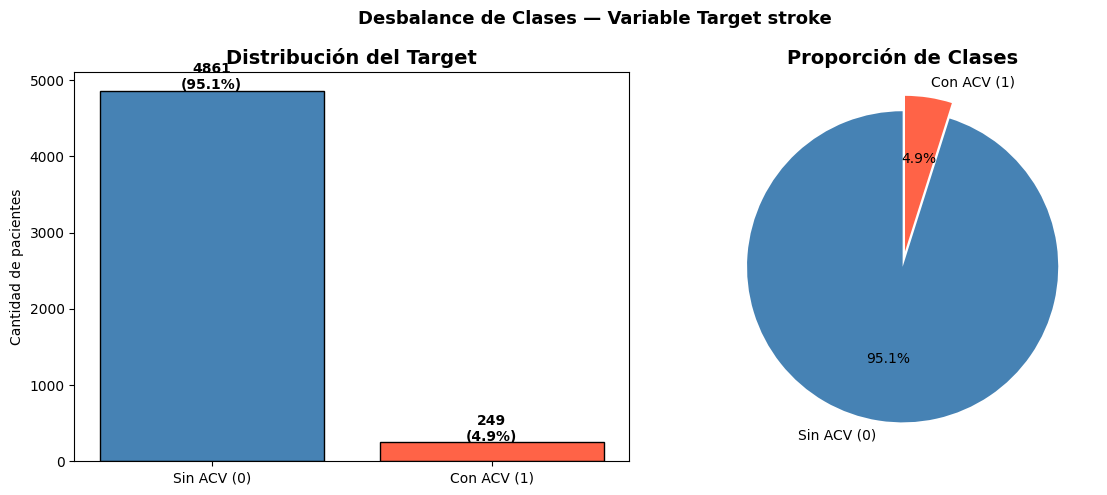

In [15]:
stroke_counts = df['stroke'].value_counts()
stroke_pct    = df['stroke'].value_counts(normalize=True) * 100

print("Distribución del target 'stroke':")
print(f"  Clase 0 (Sin ACV):  {stroke_counts[0]:,} ({stroke_pct[0]:.1f}%)")
print(f"  Clase 1 (Con ACV):  {stroke_counts[1]:,} ({stroke_pct[1]:.1f}%)")
print(f"\n  Ratio desbalance: {stroke_counts[0] / stroke_counts[1]:.0f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Sin ACV (0)', 'Con ACV (1)'], stroke_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribución del Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de pacientes')
for i, v in enumerate(stroke_counts.values):
    axes[0].text(i, v + 20, f'{v}\n({stroke_pct.values[i]:.1f}%)',
                 ha='center', fontweight='bold')

axes[1].pie(stroke_counts.values,
            labels=['Sin ACV (0)', 'Con ACV (1)'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90, explode=[0, 0.1])
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.suptitle('Desbalance de Clases — Variable Target stroke',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### ADVERTENCIA: Observamos que el dataset se encuentra desbalanceado.
La *Accuracy* **NO** es una metrica valida aqui.
Usaremos: *F1-Score*, *ROC-AUC* y *Recall* como metricas principales.


### 1.3 Análisis de Variables Numéricas

Analizamos la distribución de cada variable numérica separando por clase
para detectar diferencias entre pacientes con y sin ACV.

/var/folders/ym/274bj8h57vb3s_nm09l1td000000gn/T/ipykernel_20893/1825898922.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_clases,
/var/folders/ym/274bj8h57vb3s_nm09l1td000000gn/T/ipykernel_20893/1825898922.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_clases,
/var/folders/ym/274bj8h57vb3s_nm09l1td000000gn/T/ipykernel_20893/1825898922.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_clases,


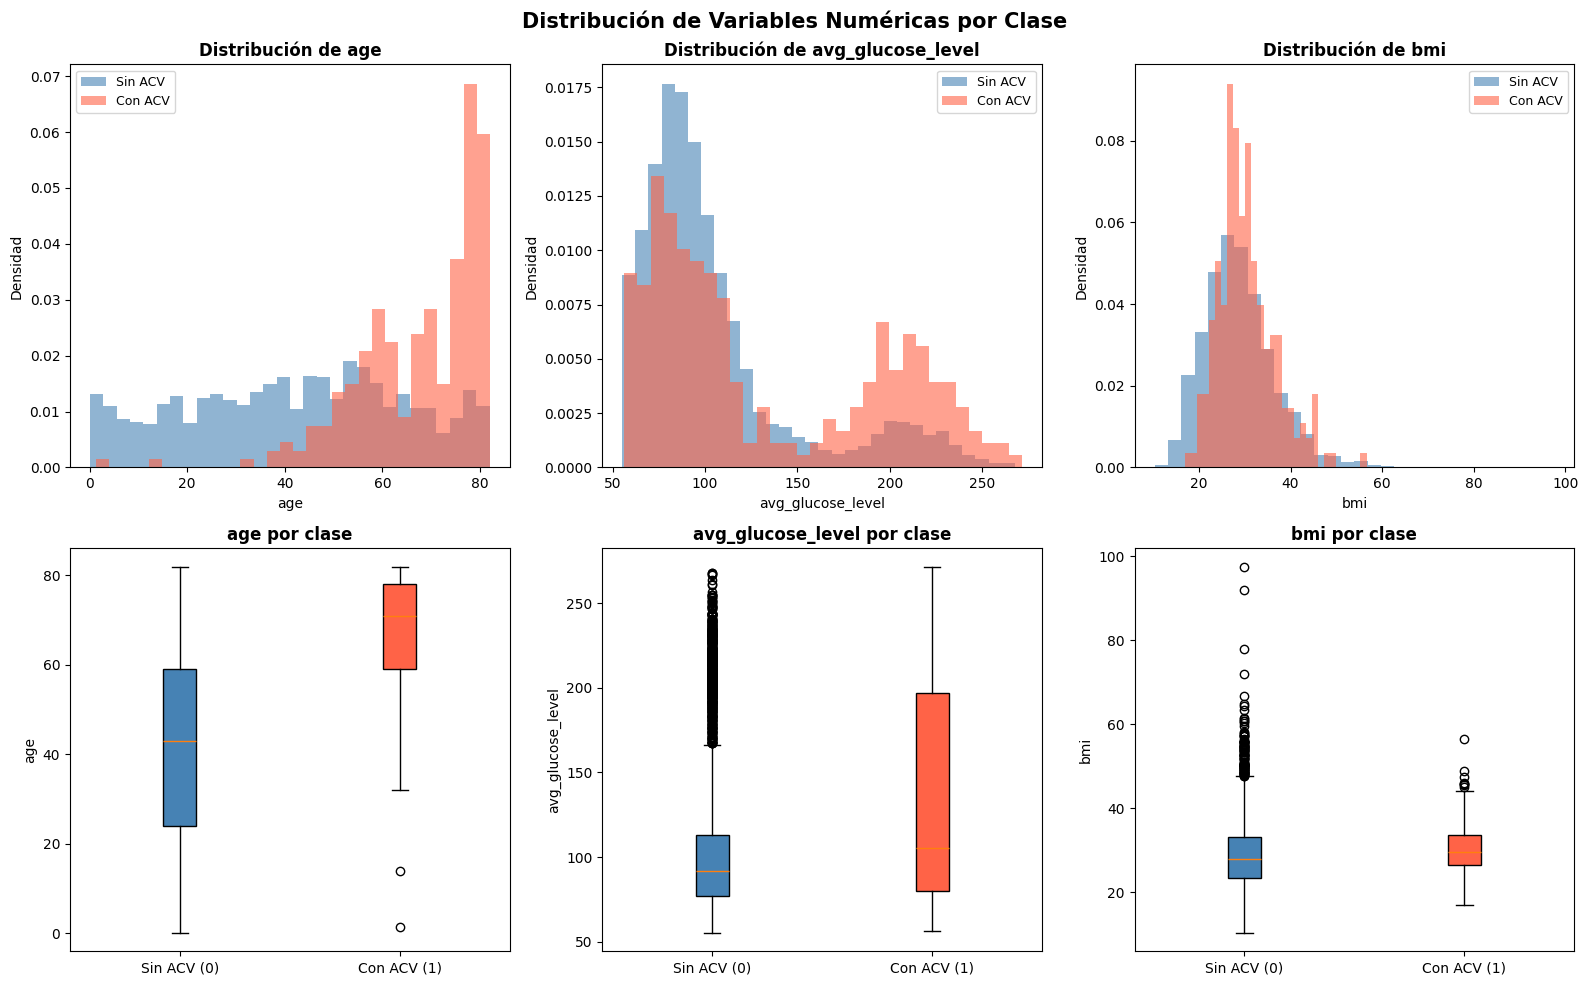

Estadísticos por clase:
          age        avg_glucose_level            bmi       
         mean median              mean  median   mean median
stroke                                                      
0       41.97   43.0            104.80   91.47  28.82   28.0
1       67.73   71.0            132.54  105.22  30.47   29.7


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables Numéricas por Clase',
             fontsize=15, fontweight='bold')

for idx, var in enumerate(vars_numericas):
    # Histograma por clase
    ax_hist = axes[0, idx]
    for label, stroke_val, color in [('Sin ACV', 0, 'steelblue'),
                                      ('Con ACV', 1, 'tomato')]:
        subset = df[df['stroke'] == stroke_val][var]
        ax_hist.hist(subset, bins=30, alpha=0.6, color=color,
                     label=f'{label}', density=True)
    ax_hist.set_title(f'Distribución de {var}', fontweight='bold')
    ax_hist.set_xlabel(var)
    ax_hist.set_ylabel('Densidad')
    ax_hist.legend(fontsize=9)

    # Boxplot por clase
    ax_box = axes[1, idx]
    data_clases = [df[df['stroke'] == 0][var].dropna(),
                   df[df['stroke'] == 1][var].dropna()]
    bp = ax_box.boxplot(data_clases,
                        labels=['Sin ACV (0)', 'Con ACV (1)'],
                        patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax_box.set_title(f'{var} por clase', fontweight='bold')
    ax_box.set_ylabel(var)

plt.tight_layout()
plt.show()

print("Estadísticos por clase:")
print(df.groupby('stroke')[vars_numericas].agg(['mean', 'median']).round(2))


> **Observación clave:** `avg_glucose_level` presenta una distribución
> **bimodal**: un pico en valores normales (~90 mg/dL) y otro en valores
> elevados (~210 mg/dL), reflejando la coexistencia de pacientes
> normoglucémicos y diabéticos. Esta característica motiva el uso de
> **Gaussian Mixture Model (GMM)** en el Bloque 3.

### 1.4 Análisis de Variables Categóricas

Calculamos la tasa de ACV dentro de cada categoría para identificar
qué grupos tienen mayor riesgo.

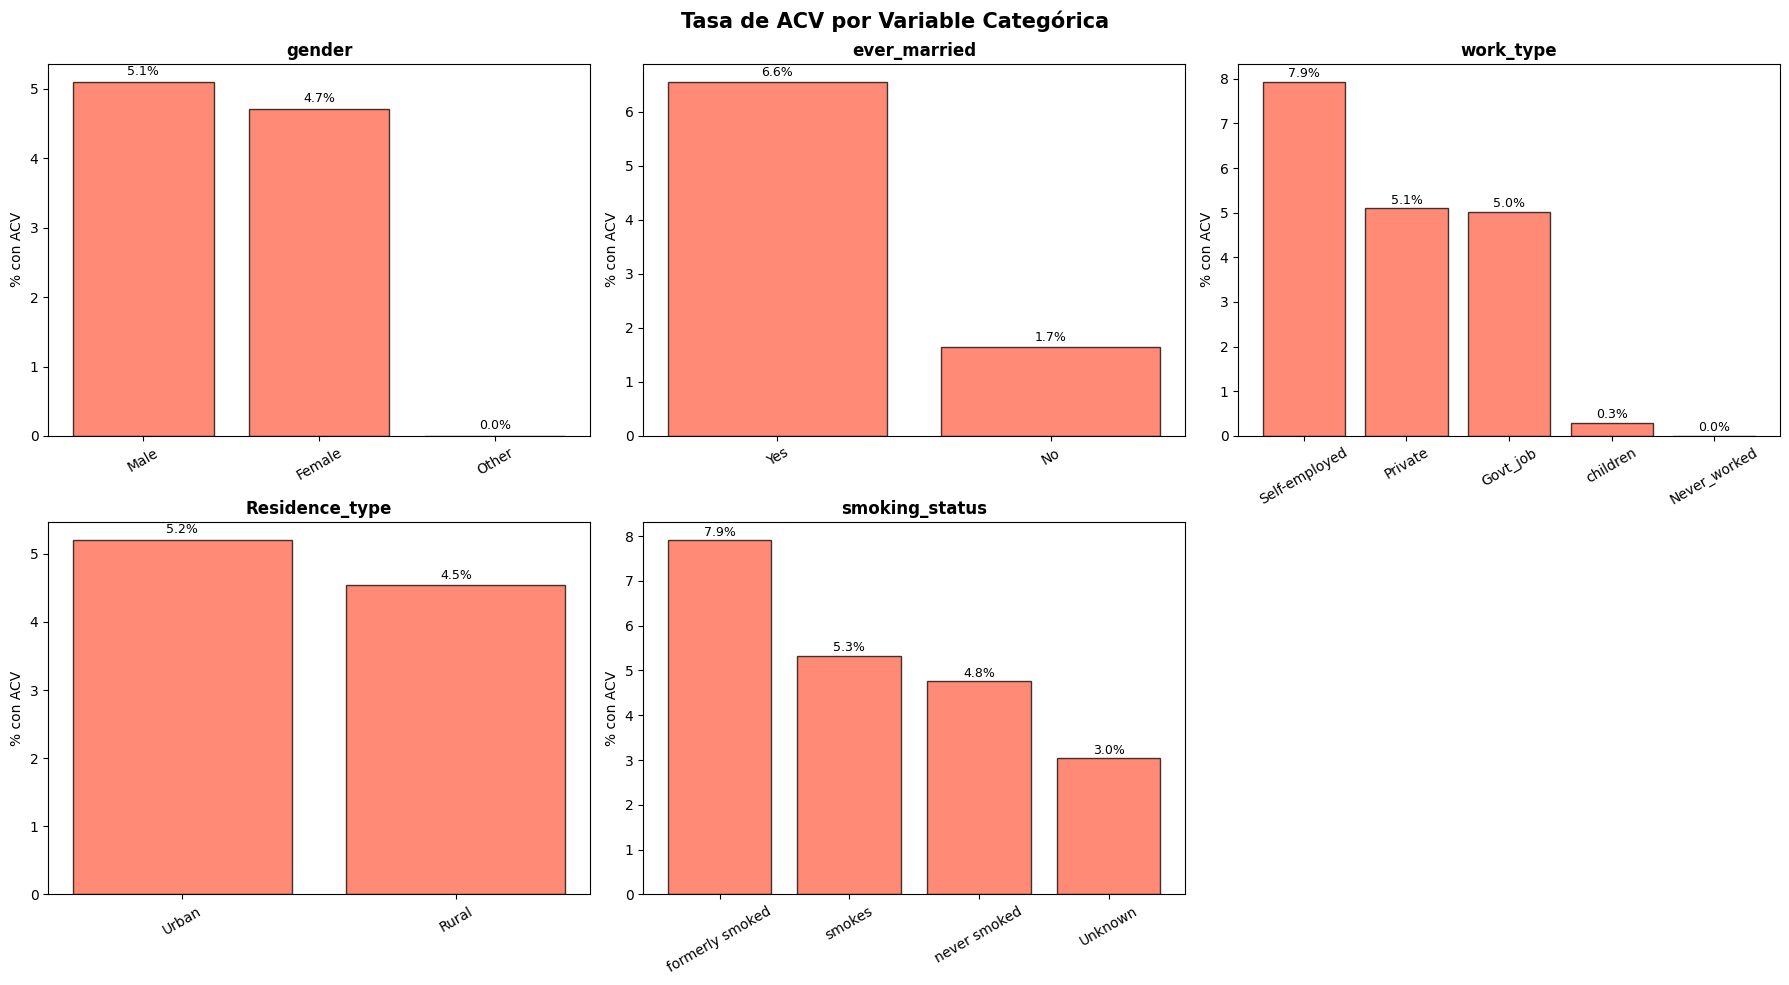

Tasa de ACV por variable categórica:

  gender:
        tasa_ACV     n
gender                
Female    0.0471  2994
Male      0.0511  2115
Other     0.0000     1

  ever_married:
              tasa_ACV     n
ever_married                
No              0.0165  1757
Yes             0.0656  3353

  work_type:
               tasa_ACV     n
work_type                    
Govt_job         0.0502   657
Never_worked     0.0000    22
Private          0.0509  2925
Self-employed    0.0794   819
children         0.0029   687

  Residence_type:
                tasa_ACV     n
Residence_type                
Rural             0.0453  2514
Urban             0.0520  2596

  smoking_status:
                 tasa_ACV     n
smoking_status                 
Unknown            0.0304  1544
formerly smoked    0.0791   885
never smoked       0.0476  1892
smokes             0.0532   789



In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tasa de ACV por Variable Categórica',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for idx, var in enumerate(vars_categoricas):
    stroke_rate = (df.groupby(var)['stroke']
                   .mean()
                   .sort_values(ascending=False))
    bars = axes[idx].bar(stroke_rate.index, stroke_rate.values * 100,
                          color='tomato', alpha=0.75, edgecolor='black')
    axes[idx].set_title(f'{var}', fontweight='bold')
    axes[idx].set_ylabel('% con ACV')
    axes[idx].tick_params(axis='x', rotation=30)
    for bar, rate in zip(bars, stroke_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width() / 2,
                       bar.get_height() + 0.1,
                       f'{rate * 100:.1f}%', ha='center', fontsize=9)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

print("Tasa de ACV por variable categórica:\n")
for var in vars_categoricas:
    print(f"  {var}:")
    print(df.groupby(var)['stroke'].agg(['mean', 'count'])
            .rename(columns={'mean': 'tasa_ACV', 'count': 'n'})
            .round(4))
    print()

### 1.5 Correlaciones

Analizamos la correlación entre variables numéricas y la correlación
de cada feature con el target `stroke`.

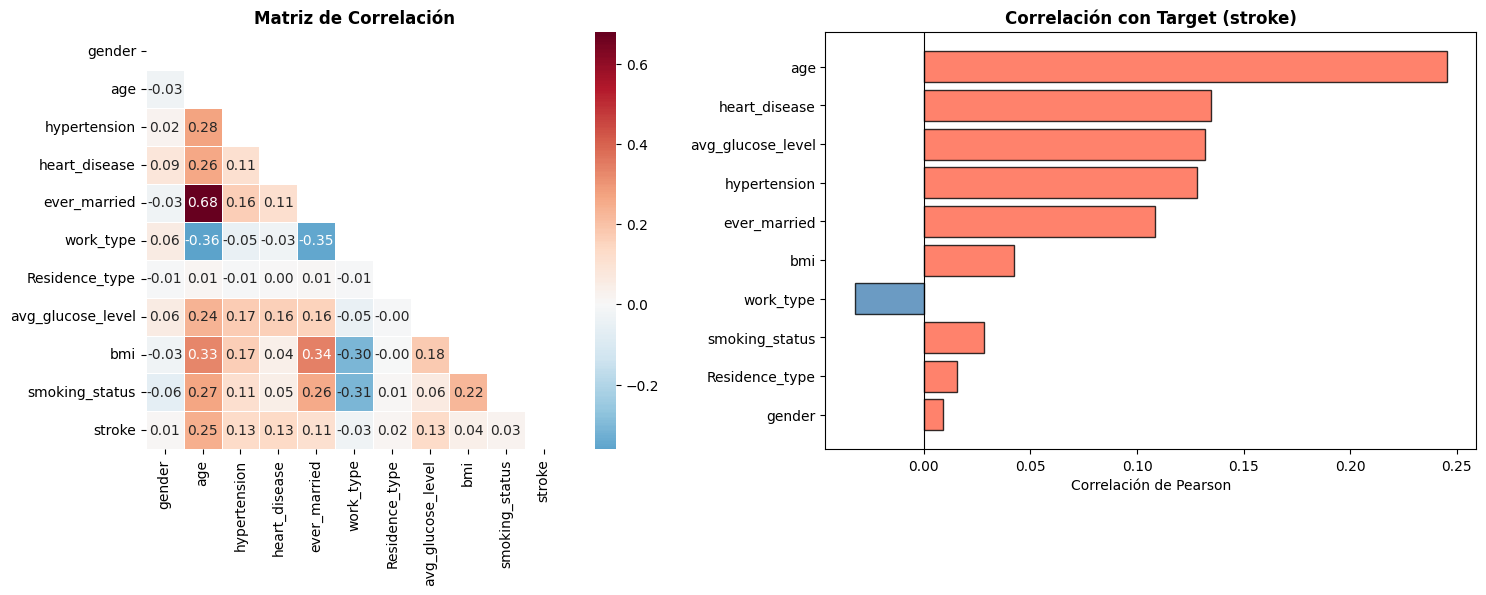

Top features correlacionadas con 'stroke' (mayor a menor):
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.042374
work_type           -0.032316
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929


In [18]:
# Encoding temporal solo para correlación (no afecta el preprocesamiento)
df_corr = df.copy()
for col in vars_categoricas:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))
df_corr = df_corr.drop(columns=['id'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap triangular
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[0], square=True,
            linewidths=0.5)
axes[0].set_title('Matriz de Correlación', fontweight='bold')

# Correlación con target
corr_target = (df_corr.corr()['stroke']
               .drop('stroke')
               .sort_values(key=abs, ascending=True))
colors_bar = ['tomato' if x > 0 else 'steelblue' for x in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values,
             color=colors_bar, edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación con Target (stroke)', fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.show()

print("Top features correlacionadas con 'stroke' (mayor a menor):")
print(corr_target.sort_values(key=abs, ascending=False).to_string())

### 1.6 Análisis de Valores Nulos

Identificamos las columnas con valores faltantes y analizamos si el
missingness en `bmi` es aleatorio (MAR) o sistemático (MNAR).

In [19]:
nulos     = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

print("Valores nulos por columna:")
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
print(nulos_df)

print("\n¿El missingness en 'bmi' es aleatorio?\n")
print("\n¿bmi_missing = 0  ==> Personas con BMI registrado")
print("\n¿bmi_missing = 1  ==> Personas sin BMI (dato faltante)\n")
df['bmi_missing'] = df['bmi'].isnull().astype(int)
print(df.groupby('bmi_missing')[['age', 'avg_glucose_level', 'stroke']]
        .mean().round(3))
print("\n-> Si los grupos son similares el missingness es MAR (Missing At Random)")
print("   -> Imputación por mediana o KNN es una estrategia válida.")
df.drop(columns=['bmi_missing'], inplace=True)

Valores nulos por columna:
                   Nulos  Porcentaje (%)
id                     0            0.00
gender                 0            0.00
age                    0            0.00
hypertension           0            0.00
heart_disease          0            0.00
ever_married           0            0.00
work_type              0            0.00
Residence_type         0            0.00
avg_glucose_level      0            0.00
bmi                  201            3.93
smoking_status         0            0.00
stroke                 0            0.00

¿El missingness en 'bmi' es aleatorio?


¿bmi_missing = 0  ==> Personas con BMI registrado

¿bmi_missing = 1  ==> Personas sin BMI (dato faltante)

                age  avg_glucose_level  stroke
bmi_missing                                   
0            42.865            105.305   0.043
1            52.049            126.725   0.199

-> Si los grupos son similares el missingness es MAR (Missing At Random)
   -> Imputación por mediana 